In [2]:
%load_ext autoreload
%autoreload 2
import kwant
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from koala.lattice import Lattice
from alter_morph.hamiltonians_hubb import hubb_hamiltonian,spectral_function
from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
from alter_morph.mean_field_hubb import hartree_fock
from alter_morph.kwant_utilities import Amorphous


# plotting
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

Lattice(225 vertices, 434 edges)


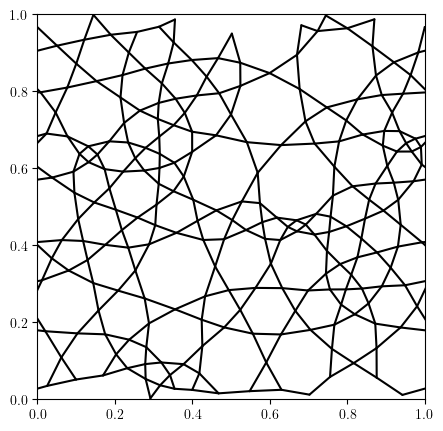

In [ ]:
# generate the lattice and set the initial conditions

import koala.graph_utils
import koala.pointsets

# create lattice
system_length = 15
lattice_type = "amorphous-4"
lattice = alter_lattice_maker(system_length, lattice_type)
lattice = koala.graph_utils.cut_boundaries(lattice, [False, True])


# set parameters, scan different values of J
t1 = 1  # hopping
Us = np.linspace(0,10,4)  # Interaction strength
filling = 1/3  # filling of the lattice

tol_mdiff = 1e-3
n_fock_steps = 100  # number of Hartree-Fock steps
lead_symmetry = np.diag([-1,1])

results = []
_,initial_m = koala.graph_color.vertex_color(lattice.edges.indices,n_colors=3)
initial_m =  initial_m-1# initial magnetization
initial_n = np.full(lattice.n_vertices, filling*2)  # initial density


fig, ax = plt.subplots(1, 1, figsize=(5, 5))
pl.plot_edges(lattice, ax=ax)
print(lattice)

hamiltonian = hubb_hamiltonian(
        lattice,
        t1,
        0,
        initial_m,
        initial_n,
    )
energies, states = la.eigh(hamiltonian)


In [10]:
for U in Us[::-1]:
    
    initial_parameters = {
        "t1": t1,
        'U':U,
        "filling": filling,
        "initial_m": initial_m,
        "initial_n": initial_n,
    }


    m_values,n_values = hartree_fock(lattice, initial_parameters, n_fock_steps,tol_mdiff=1e-2)

    # make ham and solve
    hamiltonian = hubb_hamiltonian(
        lattice,
        initial_parameters["t1"],
        initial_parameters['U'],
        m_values[-1],
        n_values[-1],
    )
    energies, states = la.eigh(hamiltonian)

    results.append(dict(initial_m=initial_m,initial_parameters=initial_parameters,m_values=m_values,n_values=n_values,lattice=lattice,energies=energies,states=states))

    initial_m = m_values[-1]  # initial magnetization
    initial_n = n_values[-1]  # initial density

results = results[::-1]


  0%|          | 0/100 [00:00<?, ?it/s]

Avg:-0.00, diff: 0.000174:   4%|▍         | 4/100 [00:00<00:09, 10.09it/s]


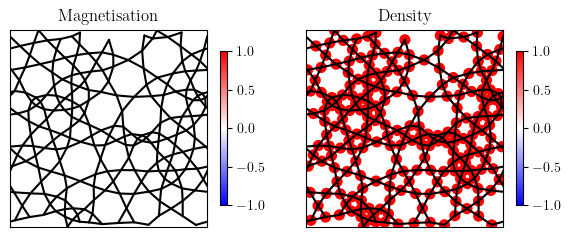

In [13]:
# plot that shit for one U
idx = -1
U = Us[idx]
m_values = results[idx]['m_values'][-1]
n_values = results[idx]['n_values'][-1]

fig, axs = plt.subplots(1, 2, figsize=(7, 5))

for ax,x,l in zip(axs,[m_values,n_values],["Magnetisation",'Density']):
    pl.plot_edges(lattice, ax=ax)
    im = ax.scatter(
        lattice.vertices.positions[:, 0],
        lattice.vertices.positions[:, 1],
        c=x,
        cmap="bwr",
        s=50,
        vmin=-1,
        vmax=1,
    )
    plt.colorbar(im, ax=ax,shrink=0.4)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(l)
# print(lattice)


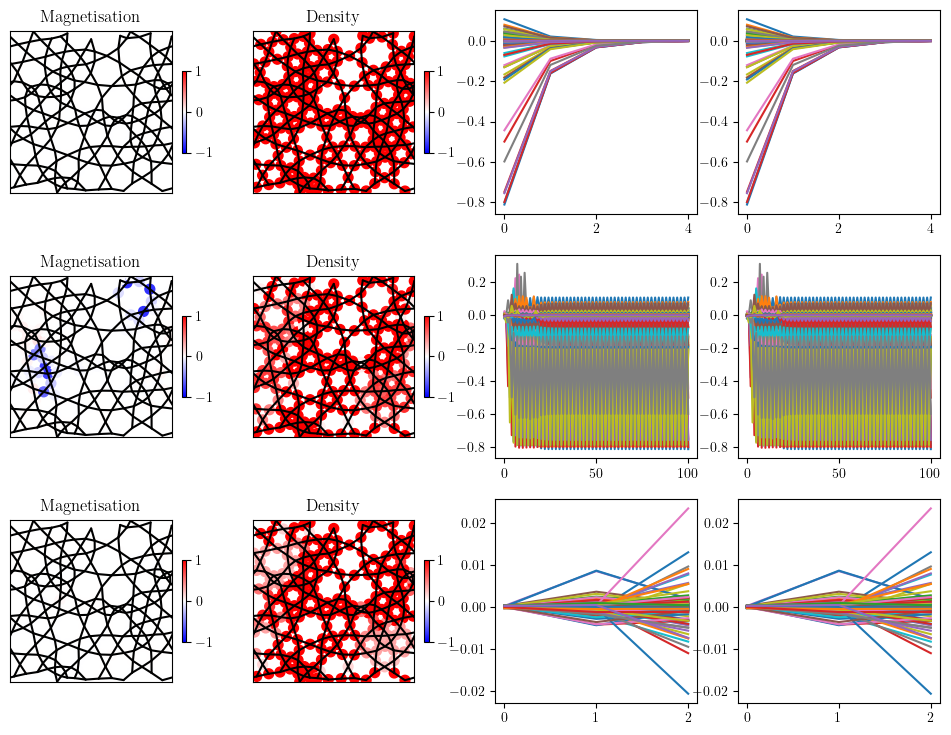

In [14]:
# plot for all U

fig, axs = plt.subplots(len(Us), 4, figsize=(12, 3*len(Us)))

for idx,axLine in enumerate(axs):
    m_values = results[idx]['m_values']
    n_values = results[idx]['n_values']
    for ax,x,l in zip(axLine[:2],[m_values,n_values],["Magnetisation",'Density']):
        pl.plot_edges(lattice, ax=ax)
        im = ax.scatter(
            lattice.vertices.positions[:, 0],
            lattice.vertices.positions[:, 1],
            c=x[-1],
            cmap="bwr",
            s=50,
            vmin=-1,
            vmax=1,
        )
        plt.colorbar(im, ax=ax,shrink=0.4)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(l)

    axLine[2].plot(m_values)
    axLine[3].plot(m_values)
    # print(lattice)


/var/folders/xb/6hhfs1vn32s_g5b9xk9fx8yh0000gn/T/ipykernel_77851/213255578.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  im = ax.scatter(


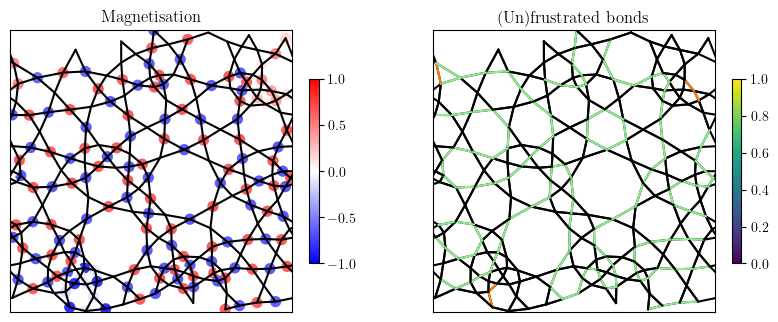

In [48]:
#number of frustrated neighbors:
edge0 = lattice.edges.indices[0]

lattice.vertices.positions[0]


# plot that shit for one U
idx = -1
m_values = results[idx]['m_values'][-1]
n_values = results[idx]['n_values'][-1]

fig, axs = plt.subplots(1, 2, figsize=(10, 6))

for ax,x,l in zip(axs,[m_values,[]],["Magnetisation",'(Un)frustrated bonds']):
    pl.plot_edges(lattice, ax=ax)
    im = ax.scatter(
        lattice.vertices.positions[:, 0],
        lattice.vertices.positions[:, 1],
        c=x,
        cmap="bwr",
        s=50,
        vmin=-1,
        vmax=1,
    )
    plt.colorbar(im, ax=ax,shrink=0.4)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(l)

ax = axs[1]



#let's plot additional stuff on the lattice:
for sites in lattice.edges.indices:

    if m_values[sites[0]]*m_values[sites[1]]<-0.1:
        color = 'lightgreen'
    elif m_values[sites[0]]*m_values[sites[1]]>0.1:
        color = 'tab:orange'
    else:
        color = 'k'

    pos0 = lattice.vertices.positions[sites[0]]
    pos1 = lattice.vertices.positions[sites[1]]

    
    if np.linalg.norm(pos0-pos1)<0.1: #plot only for bonds which are not periodic
        ax.plot([pos0[0],pos1[0]],[pos0[1],pos1[1]],color=color)



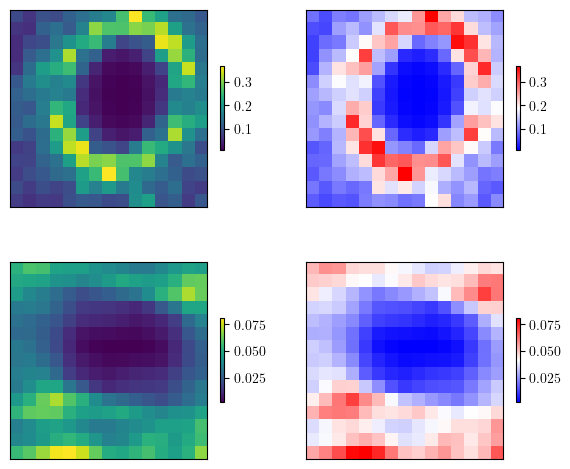

In [94]:
# plot that shit for one U
idx = 0
U = Us[idx]

fig, axs = plt.subplots(len(Us), 2, figsize=(7, 3*len(Us)))

for idx,axLine in enumerate(axs):
    result = results[idx]
    energies = result['energies']
    fermi_level = energies[int(len(energies)*filling)]

    #spectral function
    ax = axs[idx,0]
    spec = spectral_function(lattice,result['energies'],result['states'],fermi_level,eta=1e-1,local_operator=np.array([1,1]))
    im = ax.imshow(spec,origin='lower',)
    plt.colorbar(im, ax=ax,shrink=0.4)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    #spin spectral function 
    ax = axs[idx,1]
    spec = spectral_function(lattice,result['energies'],result['states'],fermi_level,eta=1e-1,local_operator=np.array([1,1]))
    im = ax.imshow(spec,origin='lower',cmap='bwr')
    plt.colorbar(im, ax=ax,shrink=0.4)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    

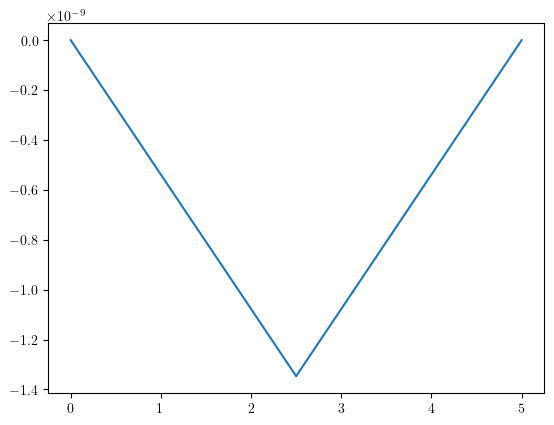

In [53]:
from alter_morph.kwant_utilities import (
        crack_hamiltonian_for_contacts_kwant,
        attach_leads_to_cracked,
    )

for result in results:

    hamiltonian = hubb_hamiltonian(
        result['lattice'],
        result['initial_parameters']["t1"],
        result['initial_parameters']['U'],
        result['m_values'][-1],
        result['n_values'][-1],
    )
    energies, states = la.eigh(hamiltonian)

    #results.append(dict(initial_m=initial_m,initial_parameters=initial_parameters,m_values=m_values,n_values=n_values,lattice=lattice,energies=energies,states=states))

    fermi_energy = np.mean(
        energies[int(result['initial_parameters']['filling'] * len(energies)) - 1 : int(result['initial_parameters']['filling'] * len(energies)) + 1]
    )


    lead_onsite = np.mean(
        [
            hamiltonian[i * 2 : (i + 1) * 2, i * 2 : (i + 1) * 2]
            for i in range(lattice.n_vertices)
        ],
        axis=0,
    )
    lead_coupling = -np.eye(2)


    # attach leads to the lattice
    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice,
        k_lattice,
        k_system,
        contact_vertices,
        lead_onsite,
        lead_coupling,
        np.diag([-1, 1]),
    )

    k_system_f = k_system.finalized()
    smatrix = kwant.smatrix(k_system_f, energy=fermi_energy)
    g = np.array(
        [[smatrix.transmission((1, j), (0, i)) for j in range(2)] for i in range(2)]
    )
    result['conductance'] = g[0,0] + g[1,1]  # total conductance
    result['spin_conductance'] = g[0,0] - g[1,1]  # spin conductance

plt.plot(Us, [r['spin_conductance'] for r in results], label='spinConductance')

